In [1]:
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

/home/z2034747/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
ds= xr.open_dataset('/home/scratch/dwefer/GEFSv12/z500_pwat_cape.nc')
ds = ds.sel(time= '2011-04-27', method= 'nearest')

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

colors = [
    "#885c1e", "#a9834b", "#c1a779", "#d9cba7", "#f1f0d6",
    "#d6e6bd", "#bcdda4", "#a3d48d", "#89ca75", "#73c05d",
    "#50aa2d", "#1d4d06", "#6ea0ad", "#5a848d", "#44686d",
    "#2f4b4d", "#182b2b", "#666698", "#5a568d", "#4d4680",
    "#3f3575", "#7e7e00", "#9c9d00", "#bcbd00", "#dcdd00",
    "#fbfc00"
]

levels = [
    0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 
    30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50
]

extent = [-122.0, -70.0, 23.0, 51.0]

base_colors = colors[:-1]
extend_color = colors[-1]
cmap = mcolors.ListedColormap(base_colors)
cmap.set_over(extend_color)
norm = mcolors.BoundaryNorm(levels, cmap.N)

gh_levels = range(5460, 5940, 60)

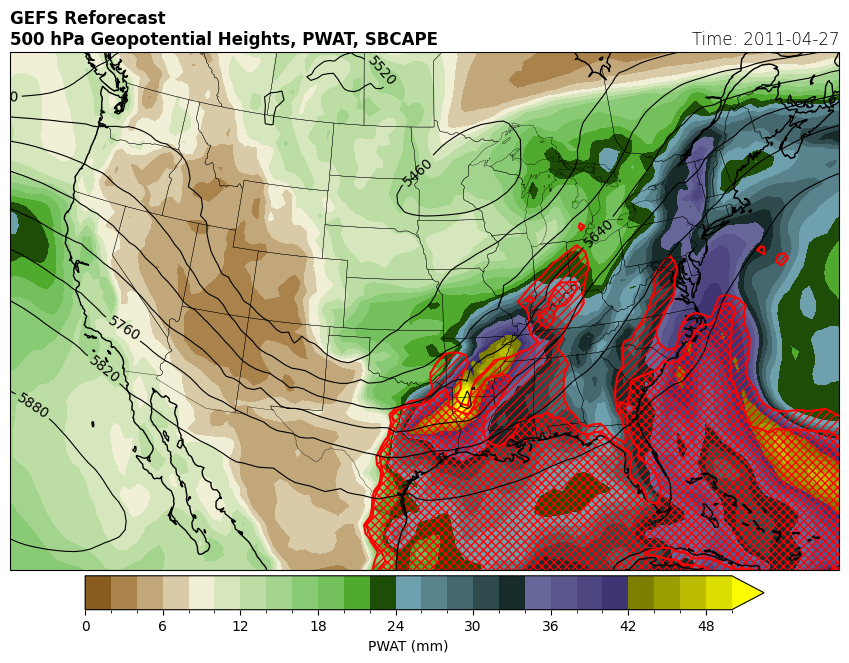

In [58]:
fig = plt.figure(figsize= (12, 8))

ax = plt.subplot(1, 1, 1, projection= ccrs.LambertConformal())

ax.set_extent(extent, crs= ccrs.PlateCarree())

ds.pwat.plot.contourf(ax= ax, colors= cmap, levels= levels, norm= norm, extend= 'max', cbar_kwargs= {'label': 'PWAT (mm)', 'orientation': 'horizontal', 'shrink': 0.73, 'pad': 0.01}, transform= ccrs.PlateCarree())
c = ds.gh.plot.contour(ax= ax, levels = gh_levels, colors= 'k', linewidths = 0.8, transform= ccrs.PlateCarree(), zorder= 10)
ax.clabel(c, inline= True)


with plt.rc_context({"hatch.color": "red", "hatch.linewidth": 0.1}):
    ax.contourf(ds.longitude, ds.latitude, ds.cape.values, levels= [0, 500, 1000, 60000], colors = 'none', hatches= [None, '////', 'xxxx'], transform= ccrs.PlateCarree())
           
ax.contour(ds.longitude, ds.latitude, ds.cape.values, levels = [500, 1000, 60000], colors= 'red', transform= ccrs.PlateCarree())


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidths= 0.25)

ax.set_title('')
ax.set_title('GEFS Reforecast\n500 hPa Geopotential Heights, PWAT, SBCAPE', loc= 'left', fontweight= 'bold')
ax.set_title('Time: 2011-04-27', loc= 'right', fontweight= 'light')

plt.savefig('./Figures/sample_plot.png', dpi= 300, bbox_inches= 'tight')